# Full-page passport embeddings with EfficientNet-B0

This notebook transforms each complete document-page image into a fixed vector using a pretrained EfficientNet-B0 model.

Unlike the earlier multi-scale version, this notebook uses:

- one complete page per image;
- no tiles;
- no local-view pooling;
- one 1,280-dimensional vector per page.

The page is padded to a square before resizing so its original aspect ratio is preserved. The approach is faster and simpler than tiling, but small passports may lose detail when a large A4 page is reduced to the model's 224 × 224 input.

Reference: [TorchVision EfficientNet-B0 documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html).


## 1. Installation

Run this cell only if the packages are missing. On Windows, install PyTorch using the command produced by the official PyTorch installer for your CPU or CUDA configuration.


In [8]:
%pip install -q torch torchvision pillow numpy pandas scikit-learn matplotlib tqdm joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and configuration

Input:

- images under `dataset_images/`;
- optional `labels.csv` containing `relative_path,label`;
- optional `document_id` column for document-level train/test splitting.

Labels: `0` = no passport, `1` = passport.


In [9]:
from contextlib import nullcontext
from pathlib import Path
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("data/pages")
OUTPUT_DIR = Path("passport_full_image_output")
LABELS_FILE = Path("passport_page_labels_big_dataset.csv")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE)


Device: cpu


## 3. Find all input images


In [10]:
image_paths = sorted(
    path for path in DATA_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

files_df = pd.DataFrame({
    "relative_path": [path.relative_to(DATA_DIR).as_posix() for path in image_paths],
    "image_name": [path.name for path in image_paths],
    "image_path": [str(path) for path in image_paths],
})

print(f"Found {len(files_df):,} images")
display(files_df.head())

if files_df.empty:
    raise FileNotFoundError(
        f"No JPG/JPEG/PNG images were found under: {DATA_DIR.resolve()}"
    )


Found 839 images


,relative_path,image_name,image_path
0,filler_text/passport_edge_00001_p02.jpg,passport_edge_00001_p02.jpg,data\pages\filler_text\passport_edge_00001_p02...
1,filler_text/passport_edge_00003_p01.jpg,passport_edge_00003_p01.jpg,data\pages\filler_text\passport_edge_00003_p01...
2,filler_text/passport_edge_00005_p02.jpg,passport_edge_00005_p02.jpg,data\pages\filler_text\passport_edge_00005_p02...
3,filler_text/passport_edge_00005_p03.jpg,passport_edge_00005_p03.jpg,data\pages\filler_text\passport_edge_00005_p03...
4,filler_text/passport_edge_00007_p01.jpg,passport_edge_00007_p01.jpg,data\pages\filler_text\passport_edge_00007_p01...


## 4. Prepare the complete page

`exif_transpose` applies the orientation stored by cameras and phones. The image is then converted to RGB.

An A4 page is not square. Directly forcing it into a square would distort faces, text, and document proportions. The `letterbox_square` function therefore adds white padding around the page without stretching it.


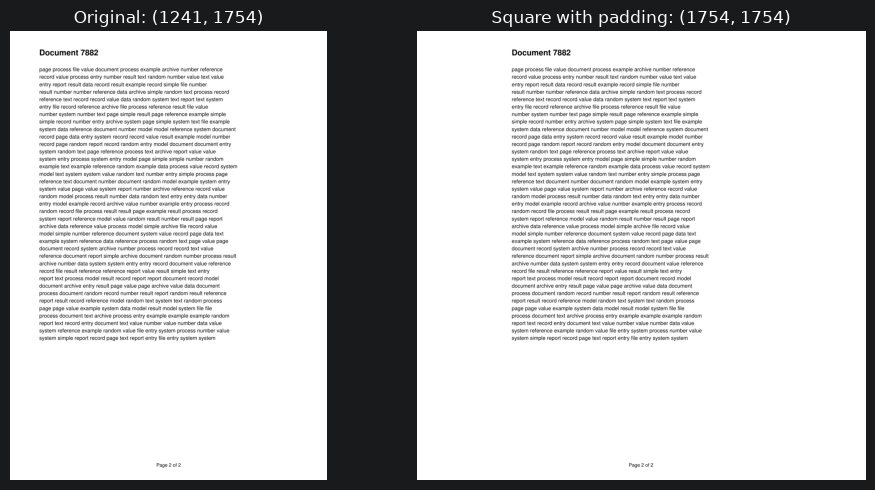

In [11]:
def open_rgb(path):
    image = Image.open(path)
    image = ImageOps.exif_transpose(image)
    return image.convert("RGB")


def letterbox_square(image, fill=(255, 255, 255)):
    side = max(image.size)
    canvas = Image.new("RGB", (side, side), fill)
    x = (side - image.width) // 2
    y = (side - image.height) // 2
    canvas.paste(image, (x, y))
    return canvas


sample_path = image_paths[0]
sample_image = open_rgb(sample_path)
sample_square = letterbox_square(sample_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_image)
axes[0].set_title(f"Original: {sample_image.size}")
axes[0].axis("off")

axes[1].imshow(sample_square)
axes[1].set_title(f"Square with padding: {sample_square.size}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 5. Load EfficientNet-B0 as a feature extractor

The official pretrained weights and their matching preprocessing are used. The original ImageNet classification layer is replaced with `Identity`, so the model returns its 1,280-dimensional representation instead of 1,000 ImageNet class scores.


In [12]:
weights = EfficientNet_B0_Weights.DEFAULT
preprocess = weights.transforms()

encoder = efficientnet_b0(weights=weights)
encoder.classifier = nn.Identity()
encoder = encoder.to(DEVICE).eval()

VECTOR_DIM = 1280
print("Output vector size:", VECTOR_DIM)


Output vector size: 1280


## 6. Transform every complete image into a vector

Processing is performed in batches. Every page is:

1. opened and corrected for EXIF orientation;
2. padded to a square;
3. resized, cropped and normalized by the official weight transform;
4. passed once through EfficientNet-B0;
5. L2-normalized to produce a 1,280-value vector.


In [13]:
def amp_context():
    if DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


vectors = []
metadata = []

for start in tqdm(range(0, len(files_df), BATCH_SIZE), desc="Image batches"):
    batch_df = files_df.iloc[start:start + BATCH_SIZE]
    tensors = []
    valid_rows = []

    for row in batch_df.itertuples(index=False):
        try:
            image = open_rgb(row.image_path)
            square = letterbox_square(image)
            tensors.append(preprocess(square))
            valid_rows.append((row, image.width, image.height))
        except Exception as exc:
            metadata.append({
                "relative_path": row.relative_path,
                "image_name": row.image_name,
                "image_path": row.image_path,
                "width": np.nan,
                "height": np.nan,
                "status": "failed",
                "error": repr(exc),
                "vector_row": np.nan,
            })

    if not tensors:
        continue

    batch_tensor = torch.stack(tensors).to(DEVICE)

    with torch.inference_mode(), amp_context():
        batch_vectors = encoder(batch_tensor)
        batch_vectors = F.normalize(batch_vectors.float(), p=2, dim=1)

    batch_vectors = batch_vectors.cpu().numpy().astype(np.float32)

    for vector, (row, width, height) in zip(batch_vectors, valid_rows):
        vectors.append(vector)
        metadata.append({
            "relative_path": row.relative_path,
            "image_name": row.image_name,
            "image_path": row.image_path,
            "width": width,
            "height": height,
            "status": "ok",
            "error": "",
            "vector_row": len(vectors) - 1,
        })

if not vectors:
    raise RuntimeError("No image was transformed successfully.")

X = np.stack(vectors).astype(np.float32)
metadata_df = pd.DataFrame(metadata)
ok_df = (
    metadata_df.loc[metadata_df["status"] == "ok"]
    .sort_values("vector_row")
    .reset_index(drop=True)
)

print("Embedding matrix:", X.shape)
print("Failures:", int((metadata_df["status"] == "failed").sum()))
print("First vector L2 norm:", np.linalg.norm(X[0]))


Image batches: 100%|██████████| 27/27 [03:03<00:00,  6.78s/it]

Embedding matrix: (839, 1280)
Failures: 0
First vector L2 norm: 0.9999999


## 7. Save the vectors and metadata


In [14]:
np.savez_compressed(
    OUTPUT_DIR / "full_page_embeddings.npz",
    X=X,
    relative_path=ok_df["relative_path"].to_numpy(dtype=str),
    image_name=ok_df["image_name"].to_numpy(dtype=str),
)

metadata_df.to_csv(
    OUTPUT_DIR / "full_page_embedding_metadata.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved vectors:", OUTPUT_DIR / "full_page_embeddings.npz")
print("Saved metadata:", OUTPUT_DIR / "full_page_embedding_metadata.csv")
display(ok_df.head())


Saved vectors: passport_full_image_output\full_page_embeddings.npz
Saved metadata: passport_full_image_output\full_page_embedding_metadata.csv


,relative_path,image_name,image_path,width,height,status,error,vector_row
0,filler_text/passport_edge_00001_p02.jpg,passport_edge_00001_p02.jpg,data\pages\filler_text\passport_edge_00001_p02...,1241,1754,ok,,0
1,filler_text/passport_edge_00003_p01.jpg,passport_edge_00003_p01.jpg,data\pages\filler_text\passport_edge_00003_p01...,1275,1650,ok,,1
2,filler_text/passport_edge_00005_p02.jpg,passport_edge_00005_p02.jpg,data\pages\filler_text\passport_edge_00005_p02...,1241,1754,ok,,2
3,filler_text/passport_edge_00005_p03.jpg,passport_edge_00005_p03.jpg,data\pages\filler_text\passport_edge_00005_p03...,1241,1754,ok,,3
4,filler_text/passport_edge_00007_p01.jpg,passport_edge_00007_p01.jpg,data\pages\filler_text\passport_edge_00007_p01...,1241,1754,ok,,4


## 8. Optional baseline classifier

The baseline uses the 1,280-value full-page vectors. If `document_id` exists in `labels.csv`, pages from the same source document are kept together. Otherwise, a stratified page-level split is used.

For reliable evaluation, add `document_id` whenever several images came from the same PDF or Word document.


Split: stratified by page label (no document grouping)
              precision    recall  f1-score   support

 No passport     1.0000    1.0000    1.0000       119
    Passport     1.0000    1.0000    1.0000        49

    accuracy                         1.0000       168
   macro avg     1.0000    1.0000    1.0000       168
weighted avg     1.0000    1.0000    1.0000       168

ROC AUC: 1.0


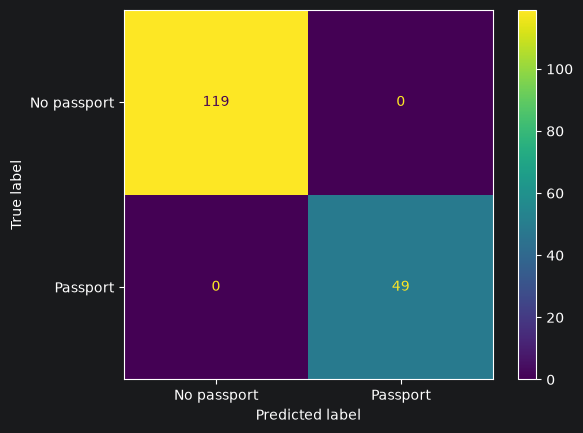

Saved baseline classifier.


In [15]:
if not LABELS_FILE.exists():
    print(
        "labels.csv was not found. Create it with columns:\n"
        "relative_path,label\n"
        "Optionally add document_id for document-level splitting."
    )
else:
    labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")
    required_columns = {"image_path", "label"}
    missing_columns = required_columns - set(labels_df.columns)

    if missing_columns:
        raise ValueError(f"Missing label columns: {sorted(missing_columns)}")

    model_df = ok_df[["image_path", "vector_row"]].merge(
        labels_df,
        on="image_path",
        how="inner",
        validate="one_to_one",
    )

    vector_rows = model_df["vector_row"].astype(int).to_numpy()
    X_model = X[vector_rows]
    y = model_df["label"].astype(int).to_numpy()

    if "document_id" in model_df.columns:
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=0.20,
            random_state=SEED,
        )
        train_idx, test_idx = next(
            splitter.split(X_model, y, groups=model_df["document_id"])
        )
        split_description = "grouped by document_id"
    else:
        all_indices = np.arange(len(model_df))
        train_idx, test_idx = train_test_split(
            all_indices,
            test_size=0.20,
            random_state=SEED,
            stratify=y,
        )
        split_description = "stratified by page label (no document grouping)"

    classifier = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        ),
    )

    classifier.fit(X_model[train_idx], y[train_idx])
    predictions = classifier.predict(X_model[test_idx])
    probabilities = classifier.predict_proba(X_model[test_idx])[:, 1]

    print("Split:", split_description)
    print(classification_report(
        y[test_idx],
        predictions,
        target_names=["No passport", "Passport"],
        digits=4,
        zero_division=0,
    ))

    if len(np.unique(y[test_idx])) == 2:
        print("ROC AUC:", round(roc_auc_score(y[test_idx], probabilities), 4))

    ConfusionMatrixDisplay.from_predictions(
        y[test_idx],
        predictions,
        display_labels=["No passport", "Passport"],
    )
    plt.show()

    joblib.dump(
        classifier,
        OUTPUT_DIR / "full_page_logistic_baseline.joblib",
    )
    print("Saved baseline classifier.")


## 9. Interpreting the comparison

| Representation | Vector size | Main advantage | Main limitation |
|---|---:|---|---|
| Full page only | 1,280 | Faster, simpler, less storage | Small passports and MRZ details may disappear |
| Full page + tiles | 5,120 | Preserves local passport detail | Slower and more complex |

Compare the two methods using the same train/test split. If the full-page model performs similarly, prefer it because it is simpler. If passport recall drops, the removed tiles were preserving important local evidence.

A fixed embedding trains only the classifier placed above EfficientNet. Fine-tuning the convolutional layers requires running the images through the network during every training step.
